# CrisisLens: Disaster Tweet Classification using NLP

**Project:** Classifying tweets as *disaster-related* or *not disaster-related* using Natural Language Processing and classical Machine Learning models.

**Dataset:** `tweets.csv` — 11,370 tweets with columns `id`, `keyword`, `location`, `text`, `target` (1 = real disaster, 0 = not a disaster).

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Text cleaning & preprocessing (regex cleaning, stopword removal, lemmatization)
3. Feature extraction with TF-IDF (unigrams + bigrams)
4. Training & comparing 4 models: Logistic Regression, Multinomial Naive Bayes, Linear SVM, XGBoost
5. Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
6. Saving the best model + vectorizer for the Streamlit app


In [1]:
pip install -r requirements.txt

     ---------------------------------------- 0.0/4.4 MB ? eta -:--:--
     ------- -------------------------------- 0.8/4.4 MB 5.3 MB/s eta 0:00:01
     ----------- ---------------------------- 1.3/4.4 MB 2.7 MB/s eta 0:00:02
     ------------------- -------------------- 2.1/4.4 MB 3.1 MB/s eta 0:00:01
     ------------------- -------------------- 2.1/4.4 MB 3.1 MB/s eta 0:00:01
     -------------------------- ------------- 2.9/4.4 MB 2.7 MB/s eta 0:00:01
     --------------------------------- ------ 3.7/4.4 MB 2.9 MB/s eta 0:00:01
     ---------------------------------------- 4.4/4.4 MB 2.9 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metad

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      + meson setup C:\Users\mayan\AppData\Local\Temp\pip-install-6z3cumdo\pandas_b31e0a9c2a01475c9e7fc906e3776593 C:\Users\mayan\AppData\Local\Temp\pip-install-6z3cumdo\pandas_b31e0a9c2a01475c9e7fc906e3776593\.mesonpy-5l811s32\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\mayan\AppData\Local\Temp\pip-install-6z3cumdo\pandas_b31e0a9c2a01475c9e7fc906e3776593\.mesonpy-5l811s32\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\mayan\AppData\Local\Temp\pip-install-6z3cumdo\pandas_b31e0a9c2a01475c9e7fc906e3776593
      Build dir: C:\Users\mayan\AppData\Local\Temp\pip-install-6z3cumdo\pandas_b31e0a9c2a01475c9e7fc906e3776593\.mesonpy-5l811s32\build
      Build type: native build
      Project name: pandas
      Project version: 2.2.2
    

In [2]:
import os, re, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, classification_report)
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

# All artifacts (trained model, vectorizer, metrics) and every graph generated in this
# notebook are saved to disk so they can be reused by app.py (Streamlit) and the
# project report without re-running anything.
os.makedirs('model', exist_ok=True)
os.makedirs('assets', exist_ok=True)


## 1. Load & Inspect Data

In [3]:
df = pd.read_csv('data/tweets.csv')
print("Shape:", df.shape)
df.head()


Shape: (11370, 5)


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [4]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['target'].value_counts())
print("\nTarget proportion:\n", df['target'].value_counts(normalize=True).round(3))


<class 'pandas.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        11370 non-null  int64
 1   keyword   11370 non-null  str  
 2   location  7952 non-null   str  
 3   text      11370 non-null  str  
 4   target    11370 non-null  int64
dtypes: int64(2), str(3)
memory usage: 1.8 MB

Missing values:
 id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

Target distribution:
 target
0    9256
1    2114
Name: count, dtype: int64

Target proportion:
 target
0    0.814
1    0.186
Name: proportion, dtype: float64


The dataset is **imbalanced**: roughly 81% non-disaster tweets vs 19% disaster tweets. This is handled during modeling using `class_weight='balanced'` / `scale_pos_weight`.

## 2. Exploratory Data Analysis

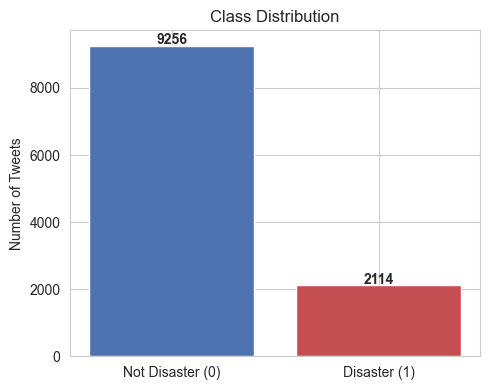

In [5]:
counts = df['target'].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(['Not Disaster (0)', 'Disaster (1)'], counts.values, color=['#4C72B0', '#C44E52'])
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.title('Class Distribution')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig('assets/class_distribution.png', bbox_inches='tight')   # saved for app.py & report
plt.show()


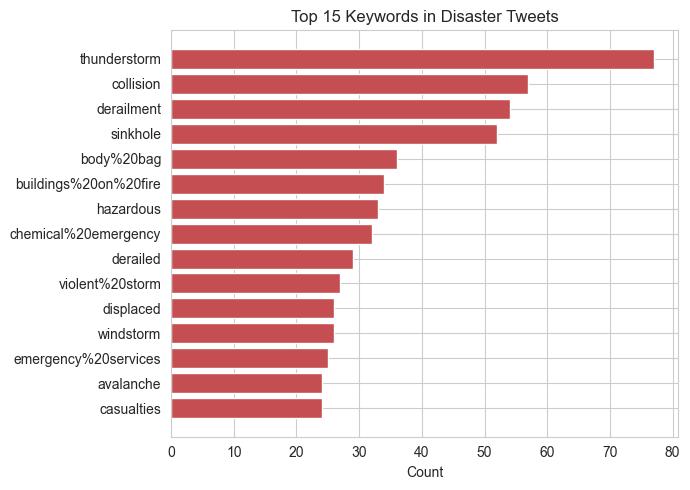

In [6]:
top_kw = df[df['target']==1]['keyword'].value_counts().head(15)
plt.figure(figsize=(7,5))
plt.barh(top_kw.index[::-1], top_kw.values[::-1], color='#C44E52')
plt.title('Top 15 Keywords in Disaster Tweets')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('assets/top_keywords.png', bbox_inches='tight')
plt.show()


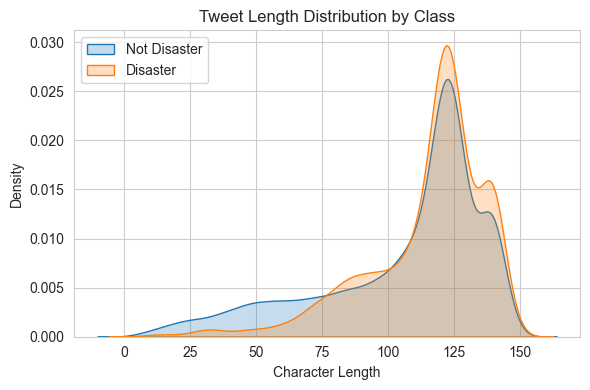

In [7]:
df['text_length'] = df['text'].str.len()
plt.figure(figsize=(6,4))
sns.kdeplot(df[df['target']==0]['text_length'], label='Not Disaster', fill=True)
sns.kdeplot(df[df['target']==1]['text_length'], label='Disaster', fill=True)
plt.title('Tweet Length Distribution by Class')
plt.xlabel('Character Length')
plt.legend()
plt.tight_layout()
plt.savefig('assets/text_length_dist.png', bbox_inches='tight')
plt.show()


## 3. Text Cleaning & Preprocessing

Steps: lowercase → remove URLs/mentions/hashtag symbols → remove punctuation & digits → remove stopwords → lemmatize.

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)      # URLs
    text = re.sub(r'@\w+', ' ', text)                         # mentions
    text = re.sub(r'#', ' ', text)                             # hashtag symbol (keep word)
    text = re.sub(r'[^a-z\s]', ' ', text)                     # punctuation/digits
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(10)


,text,clean_text
0,"Communal violence in Bhainsa, Telangana. ""Ston...",communal violence bhainsa telangana stone pelt...
1,Telangana: Section 144 has been imposed in Bha...,telangana section imposed bhainsa january clas...
2,Arsonist sets cars ablaze at dealership https:...,arsonist set car ablaze dealership
3,Arsonist sets cars ablaze at dealership https:...,arsonist set car ablaze dealership
4,"""Lord Jesus, your love brings freedom and pard...",lord jesus love brings freedom pardon fill hol...
5,"If this child was Chinese, this tweet would ha...",child chinese tweet would gone viral social me...
6,Several houses have been set ablaze in Ngemsib...,several house set ablaze ngemsibaa village oku...
7,Asansol: A BJP office in Salanpur village was ...,asansol bjp office salanpur village set ablaze...
8,"National Security Minister, Kan Dapaah's side ...",national security minister kan dapaah side chi...
9,This creature who’s soul is no longer clarent ...,creature soul longer clarent blue ablaze thing...


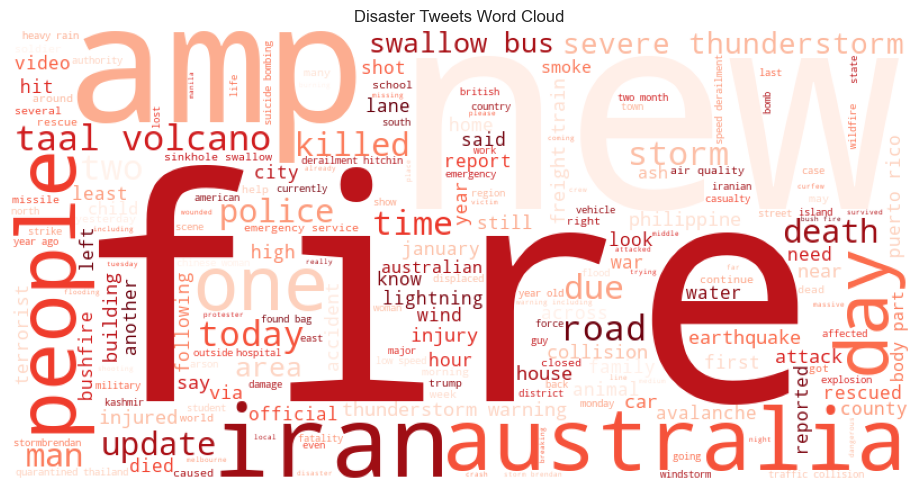

In [9]:
wc1 = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(
    ' '.join(df[df['target']==1]['clean_text']))
plt.figure(figsize=(10,5)); plt.imshow(wc1); plt.axis('off'); plt.title('Disaster Tweets Word Cloud')
plt.tight_layout(); plt.savefig('assets/wordcloud_disaster.png', bbox_inches='tight'); plt.show()


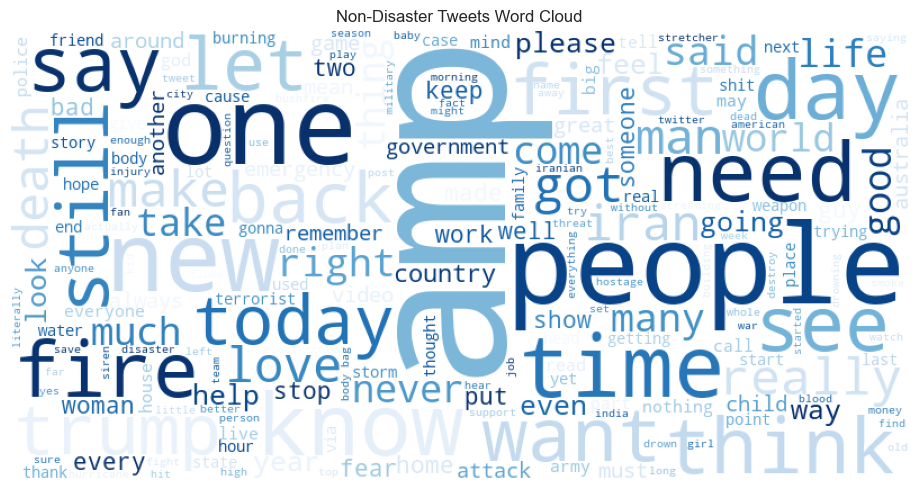

In [10]:
wc0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(
    ' '.join(df[df['target']==0]['clean_text']))
plt.figure(figsize=(10,5)); plt.imshow(wc0); plt.axis('off'); plt.title('Non-Disaster Tweets Word Cloud')
plt.tight_layout(); plt.savefig('assets/wordcloud_nondisaster.png', bbox_inches='tight'); plt.show()


## 4. Train/Test Split & TF-IDF Feature Extraction

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['target'], test_size=0.2, random_state=42, stratify=df['target'])

vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


Train shape: (9096, 8000)
Test shape: (2274, 8000)


## 5. Model Training & Comparison

Four models are trained, each addressing class imbalance via `class_weight='balanced'` (Logistic Regression, Linear SVM) or `scale_pos_weight` (XGBoost).

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Linear SVM': CalibratedClassifierCV(LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric='logloss', random_state=42)
}

results = {}
fitted = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    proba = model.predict_proba(X_test_tfidf)[:, 1]
    results[name] = dict(
        accuracy=accuracy_score(y_test, preds),
        precision=precision_score(y_test, preds),
        recall=recall_score(y_test, preds),
        f1=f1_score(y_test, preds),
        roc_auc=roc_auc_score(y_test, proba),
    )
    fitted[name] = (model, preds, proba)

results_df = pd.DataFrame(results).T.round(4)
results_df


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8518,0.5788,0.7470,0.6522,0.9063
Multinomial Naive Bayes,0.8685,0.8827,0.3381,0.4889,0.8870
Linear SVM,0.8804,0.7525,0.5319,0.6233,0.9010
XGBoost,0.8496,0.5894,0.6312,0.6096,0.8732


## 6. Evaluation

In [13]:
best_name = results_df['f1'].idxmax()
best_model, best_preds, best_proba = fitted[best_name]
print("Best model (by F1-score):", best_name)
print("\n", classification_report(y_test, best_preds, target_names=['Not Disaster','Disaster']))


Best model (by F1-score): Logistic Regression

               precision    recall  f1-score   support

Not Disaster       0.94      0.88      0.91      1851
    Disaster       0.58      0.75      0.65       423

    accuracy                           0.85      2274
   macro avg       0.76      0.81      0.78      2274
weighted avg       0.87      0.85      0.86      2274



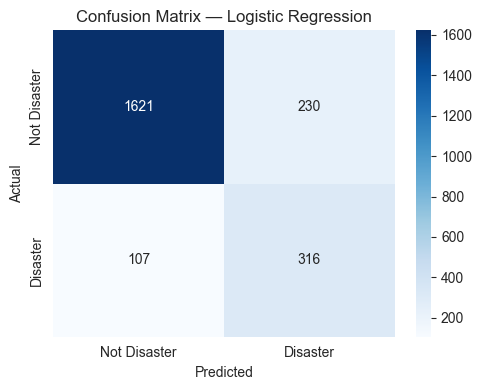

In [14]:
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster','Disaster'], yticklabels=['Not Disaster','Disaster'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('assets/confusion_matrix.png', bbox_inches='tight'); plt.show()


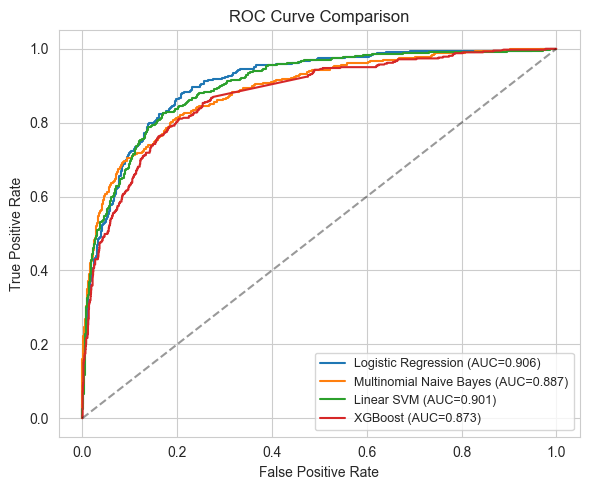

In [15]:
plt.figure(figsize=(6,5))
for name, (model, preds, proba) in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(fontsize=9)
plt.tight_layout(); plt.savefig('assets/roc_curve.png', bbox_inches='tight'); plt.show()


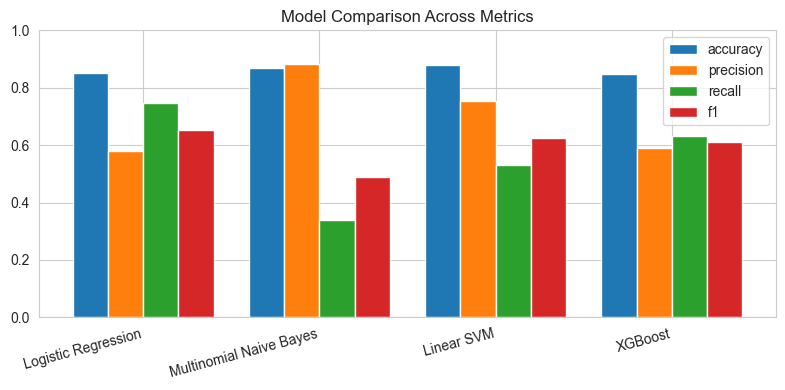

In [16]:
metric_names = ['accuracy','precision','recall','f1']
x = np.arange(len(models))
width = 0.2
plt.figure(figsize=(8,4))
for i, m in enumerate(metric_names):
    vals = [results[n][m] for n in models]
    plt.bar(x + i*width, vals, width, label=m)
plt.xticks(x + width*1.5, list(models.keys()), rotation=15, ha='right')
plt.ylim(0,1)
plt.legend()
plt.title('Model Comparison Across Metrics')
plt.tight_layout(); plt.savefig('assets/model_comparison.png', bbox_inches='tight'); plt.show()


**Model selection rationale:** Logistic Regression is chosen as the final model — it has the highest F1-score and ROC-AUC, and importantly the highest **recall** among all models. In disaster detection, missing a real disaster tweet (false negative) is far costlier than a false alarm, so recall is prioritized alongside overall balance.

## 7. Save All Artifacts (Model, Vectorizer, Metrics & Graphs)

Everything produced in this notebook is written to disk so it can be reused elsewhere without
re-running anything:

- `model/model.pkl` — the trained best model (Logistic Regression)
- `model/vectorizer.pkl` — the fitted TF-IDF vectorizer
- `model/metrics.json` — evaluation metrics for all 4 models + which one was selected
- `model/classification_report.txt` — full sklearn classification report for the best model
- `assets/*.png` — every graph generated above (class distribution, top keywords, tweet-length
  distribution, both word clouds, confusion matrix, ROC curve, model comparison chart)

`app.py` (Streamlit) loads `model/model.pkl` + `model/vectorizer.pkl` for live predictions and
displays the `assets/*.png` graphs in its **Insights** tab. The project report embeds the same
`assets/*.png` images, so the notebook is the single source of truth for every number and chart
used elsewhere in the project.

In [17]:
joblib.dump(best_model, 'model/model.pkl')
joblib.dump(vectorizer, 'model/vectorizer.pkl')

with open('model/metrics.json', 'w') as f:
    json.dump({'results': results, 'best_model': best_name}, f, indent=2)

with open('model/classification_report.txt', 'w') as f:
    f.write(f"Best Model: {best_name}\n\n")
    f.write(classification_report(y_test, best_preds, target_names=['Not Disaster','Disaster']))

print("Saved artifacts to model/:")
print(sorted(os.listdir('model')))
print("\nSaved graphs to assets/:")
print(sorted(os.listdir('assets')))


Saved artifacts to model/:
['classification_report.txt', 'metrics.json', 'model.pkl', 'vectorizer.pkl']

Saved graphs to assets/:
['class_distribution.png', 'confusion_matrix.png', 'model_comparison.png', 'roc_curve.png', 'text_length_dist.png', 'top_keywords.png', 'wordcloud_disaster.png', 'wordcloud_nondisaster.png']


## 8. Inference Demo

In [18]:
def predict_tweet(text, model=best_model, vec=vectorizer):
    cleaned = clean_text(text)
    vec_input = vec.transform([cleaned])
    pred = model.predict(vec_input)[0]
    proba = model.predict_proba(vec_input)[0][1]
    label = "DISASTER" if pred == 1 else "NOT DISASTER"
    return label, round(float(proba), 3)

samples = [
    "Massive earthquake hits the coast, thousands evacuated from their homes",
    "I'm having a great time at the beach with my friends today!",
    "Wildfire spreading rapidly near the residential area, evacuation ordered",
    "This new song is absolutely fire, on repeat all day",
]

for s in samples:
    label, conf = predict_tweet(s)
    print(f"[{label} ({conf})] {s}")


[DISASTER (0.963)] Massive earthquake hits the coast, thousands evacuated from their homes
[NOT DISASTER (0.19)] I'm having a great time at the beach with my friends today!
[DISASTER (0.622)] Wildfire spreading rapidly near the residential area, evacuation ordered
[NOT DISASTER (0.238)] This new song is absolutely fire, on repeat all day


## Conclusion

- Built a complete NLP pipeline to classify tweets as disaster-related or not.
- TF-IDF (unigram + bigram) features combined with a class-weighted **Logistic Regression** model gave the best balance of precision, recall and ROC-AUC.
- Artifacts (`model.pkl`, `vectorizer.pkl`) are saved for deployment in the accompanying Streamlit app (`app.py`).
- Future improvements: transformer-based embeddings (BERT/DistilBERT), hyperparameter tuning via GridSearch/Optuna, and incorporating `keyword`/`location` as additional features.
